In [1]:
!python -m pip install --upgrade pip


In [2]:
!pip install openpyxl

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_excel(r"C:\CMPINF\incidents_2024_thru_mar2026.xlsx")
df.head()

,Report_Number,ReportedDate,ReportedTime,Hour,DayofWeek,ReportedMonth,NIBRS_Coded_Offense,NIBRS_Offense_Code,NIBRS_Offense_Category,NIBRS_Offense_Type,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,XCOORD,YCOORD,Zone,Tract,Neighborhood,Block_Address
0,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13A AGGRAVATED ASSAULT,13A,Assault Offenses,Aggravated Assault,Person,A,18 2718 A1 Strangulation Basic - Applying,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
1,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
2,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,75 3733 A Fleeing or Attempting To Elude Polic...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
3,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,23H ALL OTHER LARCENY,23H,Larceny/Theft Offenses,All Other Larceny,Property,A,18 3921 A Theft by Unlawful Taking-Movable – L...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
4,PGHP24000017,2024-01-01,00:21,0,Monday,Jan,9999 Vehicle Offense (Not NIBRS Reportable),999,Not NIBRS Reportable,Not NIBRS Reportable,Group B,B,LO 6 101 Discharge of Firearms Prohibited,-80.0243,40.4582,Zone 1,2107,Manchester,"1200 Block of COLUMBUS AVE Pittsburgh, PA"


In [5]:
df.columns


Index(['Report_Number', 'ReportedDate', 'ReportedTime', 'Hour', 'DayofWeek',
       'ReportedMonth', 'NIBRS_Coded_Offense', 'NIBRS_Offense_Code',
       'NIBRS_Offense_Category', 'NIBRS_Offense_Type', 'NIBRS_Crime_Against',
       'NIBRS_Offense_Grouping', 'Violation', 'XCOORD', 'YCOORD', 'Zone',
       'Tract', 'Neighborhood', 'Block_Address'],
      dtype='object')

In [6]:
df = df.dropna(subset=['Neighborhood'])
df['Neighborhood'] = df['Neighborhood'].str.strip().str.lower()

In [7]:
crime_counts = df.groupby('Neighborhood').size().reset_index(name='crime_count')


In [8]:
crime_counts = crime_counts.sort_values(by='crime_count', ascending=True)

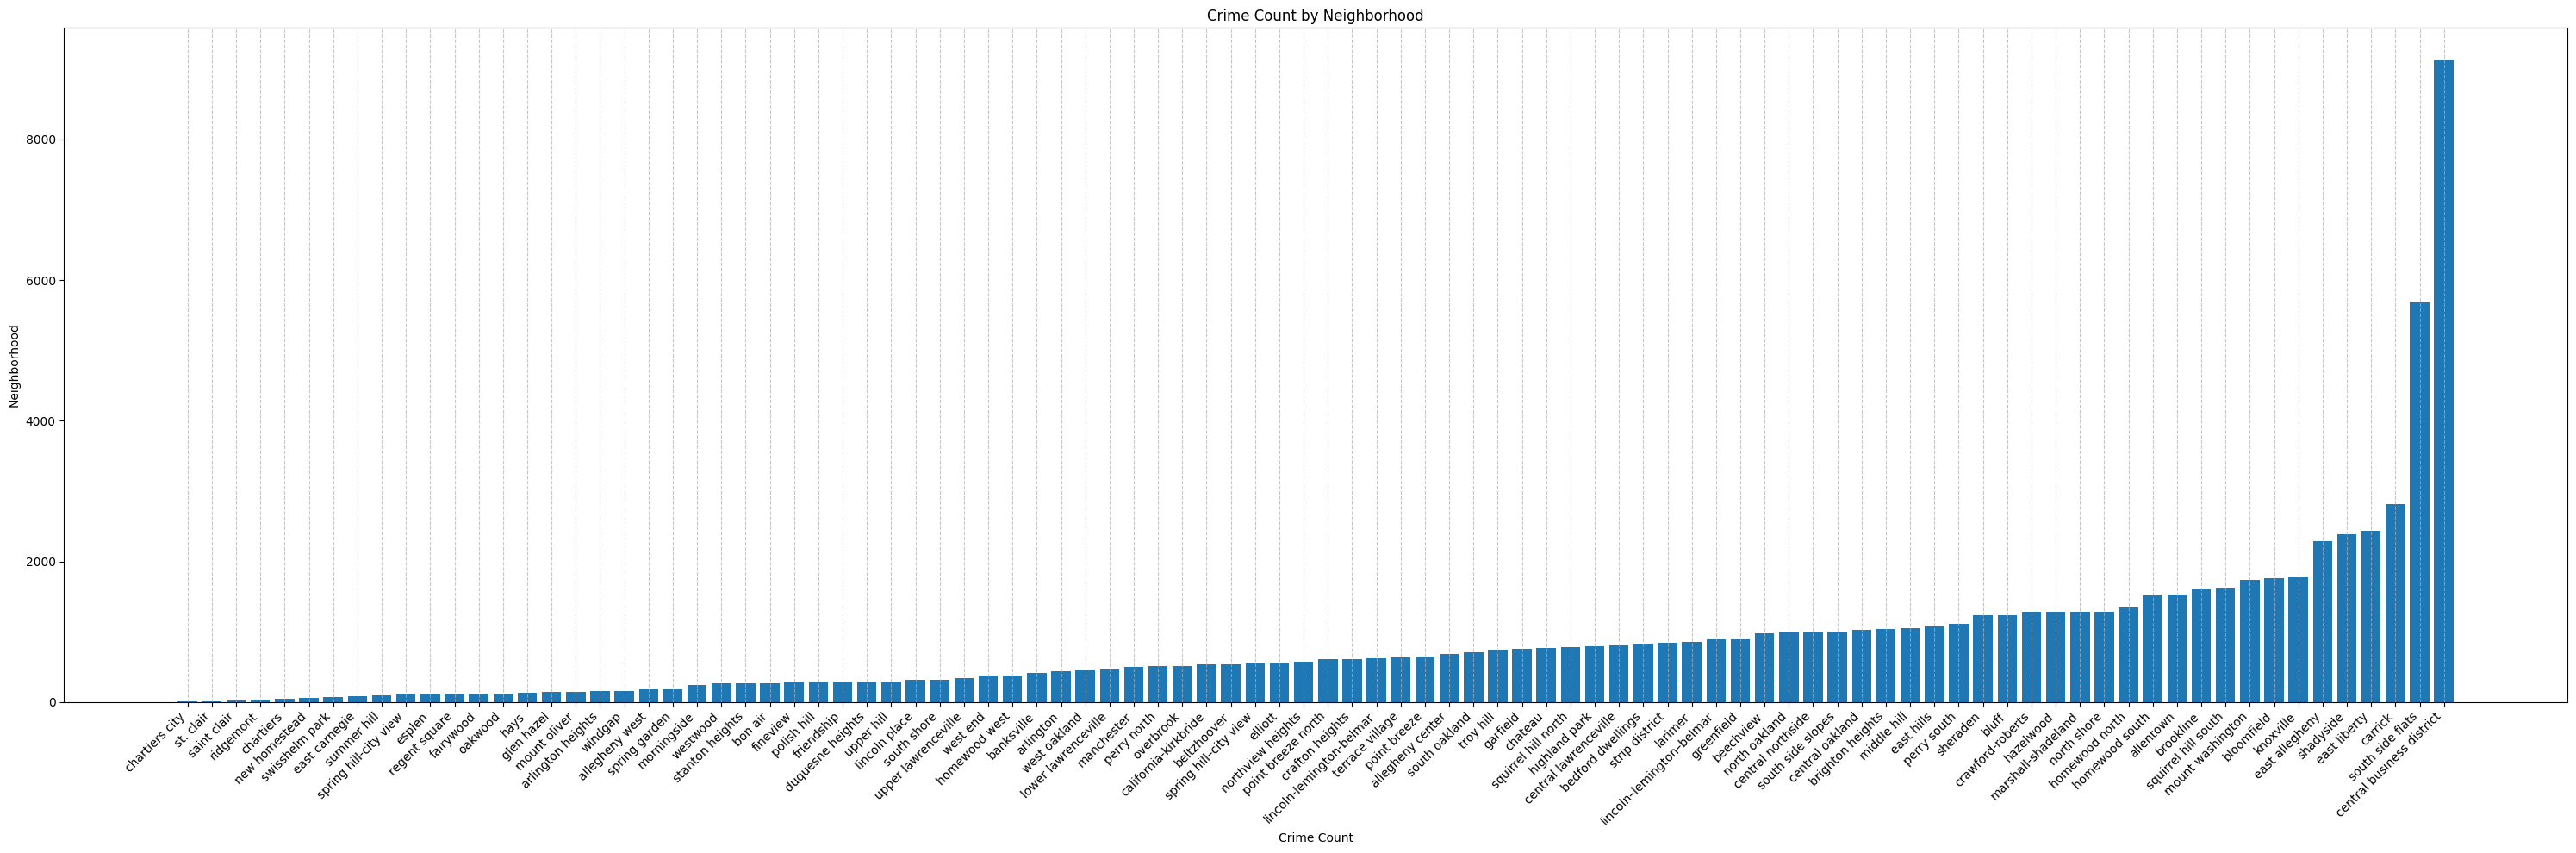

In [10]:
plt.figure(figsize=(30, 10))
plt.bar(
    crime_counts['Neighborhood'],
    crime_counts['crime_count']
)

plt.xlabel('Crime Count')
plt.ylabel('Neighborhood')
plt.title('Crime Count by Neighborhood')
plt.xticks( rotation=45,
     ha="right")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [47]:
crime_counts['crime_score'] = (
    crime_counts['crime_count'].max() - crime_counts['crime_count']
) / (
    crime_counts['crime_count'].max() - crime_counts['crime_count'].min()
)

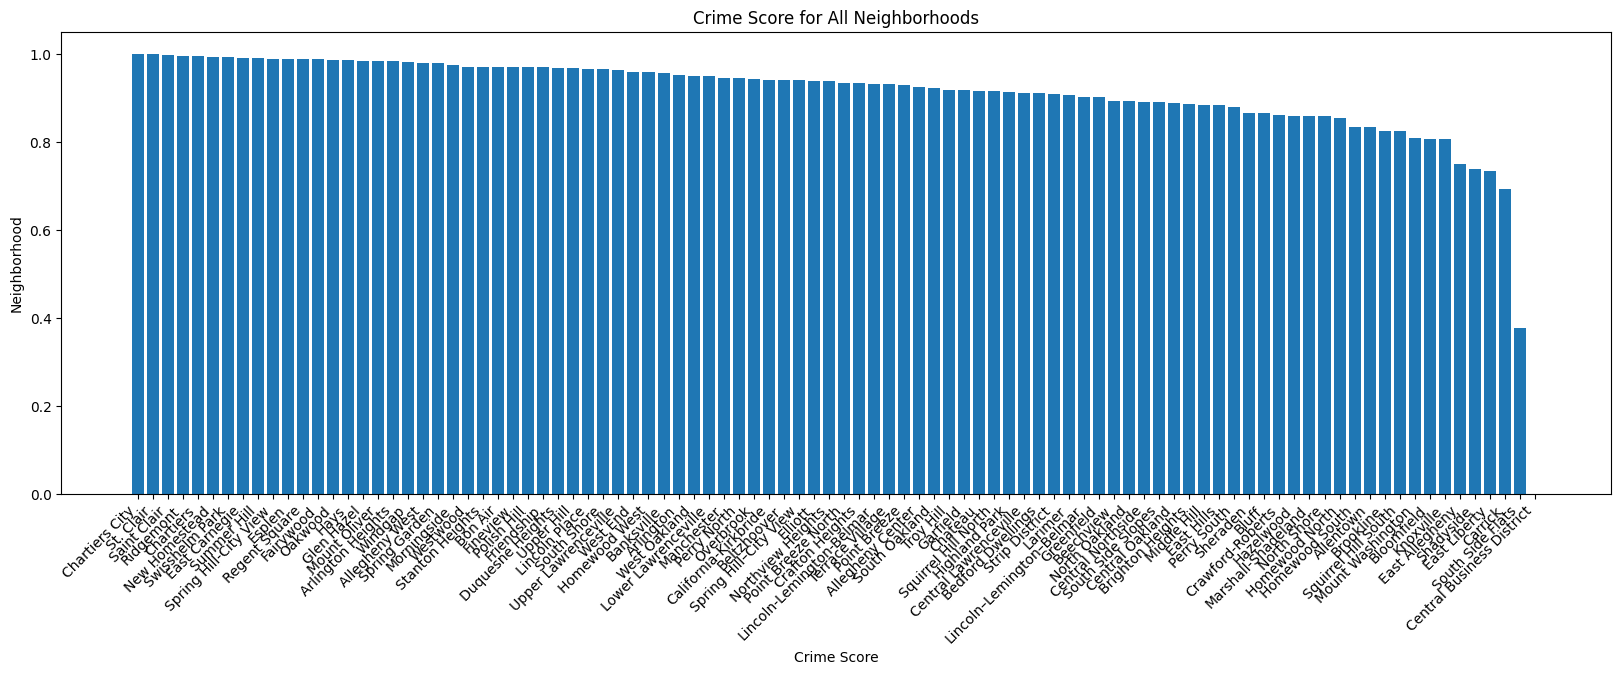

In [48]:
crime_counts_sorted = crime_counts.sort_values(by='crime_score', ascending=False)

plt.figure(figsize=(20,6)) 
plt.bar(crime_counts_sorted['Neighborhood'], crime_counts_sorted['crime_score'])

plt.xlabel("Crime Score")
plt.ylabel("Neighborhood")
plt.title("Crime Score for All Neighborhoods")
plt.xticks( rotation=45,
    ha="right")

plt.show()

## Crime Analysis

In this section,I analyzed crime data for different neighborhoods in Pittsburgh. I grouped the data by neighborhood and counted how many crime incidents happened in each area. Since fewer crimes mean a safer neighborhood, we converted the counts into a score.We normalized the values so they are between 0 and 1, and reversed them so that higher scores mean safer places.We also created visualizations to compare crime levels across neighborhoods. This result will be used later together with other data to evaluate overall livability.